C:\Users\srijo\AppData\Local\Temp\ipykernel_26740\121374706.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha='right')


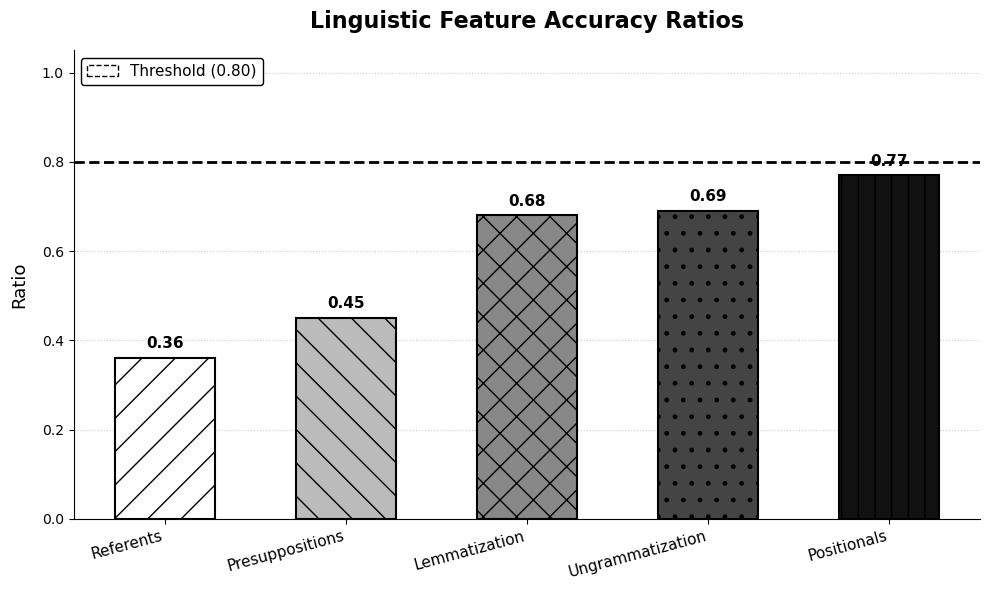

Saved to ratio_histogram_bw.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels = ['Referents', 'Presuppositions', 'Lemmatization', 'Ungrammatization', 'Positionals']
values = [0.36, 0.45, 0.68, 0.69, 0.77]

gray_fills = ['#FFFFFF', '#BBBBBB', '#888888', '#444444', '#111111']
patterns = ['/', '\\', 'x', '.', '|']

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')

bars = ax.bar(labels, values, color=gray_fills, width=0.55, zorder=3,
              edgecolor='black', linewidth=1.5)
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

ax.axhline(y=0.80, color='black', linestyle='--', linewidth=2, zorder=4)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.015,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black')

ax.set_ylim(0, 1.05)
ax.set_ylabel('Ratio', fontsize=13, color='black', labelpad=10)
ax.set_title('Linguistic Feature Accuracy Ratios', fontsize=16, fontweight='bold', color='black', pad=16)

ax.tick_params(axis='x', labelsize=11, colors='black')
ax.tick_params(axis='y', labelsize=10, colors='black')
ax.set_xticklabels(labels, rotation=15, ha='right')

ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='gray', zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

threshold_patch = mpatches.Patch(facecolor='white', edgecolor='black',
                                  linestyle='--', label='Threshold (0.80)')
ax.legend(handles=[threshold_patch], fontsize=11, loc='upper left',
          frameon=True, framealpha=1.0, edgecolor='black')

plt.tight_layout()
plt.savefig('ratio_histogram_bw.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to ratio_histogram_bw.png")

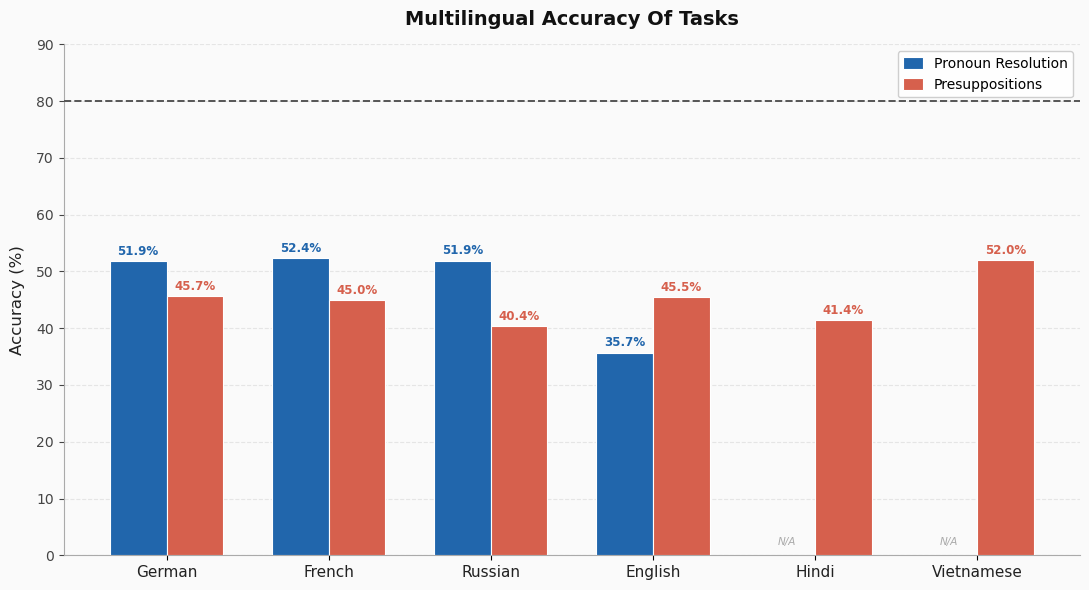

Saved to grouped_accuracy.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

languages = ['German', 'French', 'Russian', 'English', 'Hindi', 'Vietnamese']

pronoun_res = [51.85, 52.38, 51.91, 35.72, None, None]
presuppositions = [45.68, 44.99, 40.41, 45.46, 41.43, 52.03]

x = np.arange(len(languages))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

color_pr   = '#2166AC'
color_pres = '#D6604D'

bars1_vals = [v if v is not None else 0 for v in pronoun_res]
bars1 = ax.bar(x - width/2, bars1_vals, width, label='Pronoun Resolution',
               color=color_pr, edgecolor='white', linewidth=0.8, zorder=3)

bars2 = ax.bar(x + width/2, presuppositions, width, label='Presuppositions',
               color=color_pres, edgecolor='white', linewidth=0.8, zorder=3)

for i, (bar, val) in enumerate(zip(bars1, pronoun_res)):
    if val is not None:
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.6,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=8.5, color=color_pr, fontweight='bold')

for bar, val in zip(bars2, presuppositions):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.6,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=8.5, color=color_pres, fontweight='bold')

for i, val in enumerate(pronoun_res):
    if val is None:
        ax.text(x[i] - width/2, 1.5, 'N/A', ha='center', va='bottom',
                fontsize=7.5, color='#AAAAAA', style='italic')

ax.set_ylabel('Accuracy (%)', fontsize=12, color='#222222', labelpad=8)
ax.set_title('Multilingual Accuracy Of Tasks',
             fontsize=14, fontweight='bold', color='#111111', pad=14)
ax.set_xticks(x)
ax.set_xticklabels(languages, fontsize=11, color='#222222')
ax.set_ylim(0, 90)
ax.tick_params(axis='y', labelsize=10, colors='#444444')

ax.axhline(y=80, color='#555555', linestyle='--', linewidth=1.4, zorder=4)

ax.yaxis.grid(True, linestyle='--', alpha=0.45, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#AAAAAA')
ax.spines['bottom'].set_color('#AAAAAA')

legend = ax.legend(fontsize=10, loc='upper right', frameon=True,
                   framealpha=0.95, edgecolor='#CCCCCC',
                   handlelength=1.4, handleheight=1.0)

plt.tight_layout()
plt.savefig('grouped_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved to grouped_accuracy.png")